# Import Necessary Packages

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.utils.class_weight import compute_class_weight

import shap
from tqdm import tqdm

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset

In [66]:
education_and_occupation_df = pd.read_csv('/content/drive/My Drive/IS_II/datasets/education_and_occupation_data.csv')
education_and_occupation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92646 entries, 0 to 92645
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ENG.HS        92646 non-null  float64
 1   SC.HS         92646 non-null  float64
 2   MATH.HS       92646 non-null  float64
 3   CR.HS         92646 non-null  float64
 4   NS.HS         92646 non-null  float64
 5   degree        92646 non-null  object 
 6   degree.focus  92646 non-null  object 
 7   gender        92646 non-null  object 
 8   fefu          92646 non-null  object 
 9   femu          92646 non-null  object 
 10  fofu          92646 non-null  object 
 11  fomu          92646 non-null  object 
 12  int.s         92646 non-null  float64
 13  comp.s        92646 non-null  float64
 14  wasm.s        92646 non-null  float64
 15  car.s         92646 non-null  float64
 16  t.cred        92646 non-null  int64  
 17  t.parents     92646 non-null  int64  
 18  t.own         92646 non-nu

In [67]:
numeric_columns = ['ENG.HS','SC.HS', 'MATH.HS', 'CR.HS', 'NS.HS','int.s', 'comp.s', 'wasm.s', 'car.s', 't.cred', 't.parents', 't.own']

# Preprocessing

### Encoding and Standardization

In [68]:
df2_encoded = education_and_occupation_df.copy()
df2_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92646 entries, 0 to 92645
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ENG.HS        92646 non-null  float64
 1   SC.HS         92646 non-null  float64
 2   MATH.HS       92646 non-null  float64
 3   CR.HS         92646 non-null  float64
 4   NS.HS         92646 non-null  float64
 5   degree        92646 non-null  object 
 6   degree.focus  92646 non-null  object 
 7   gender        92646 non-null  object 
 8   fefu          92646 non-null  object 
 9   femu          92646 non-null  object 
 10  fofu          92646 non-null  object 
 11  fomu          92646 non-null  object 
 12  int.s         92646 non-null  float64
 13  comp.s        92646 non-null  float64
 14  wasm.s        92646 non-null  float64
 15  car.s         92646 non-null  float64
 16  t.cred        92646 non-null  int64  
 17  t.parents     92646 non-null  int64  
 18  t.own         92646 non-nu

In [69]:
# Define the categories for each column
categories_dict = {
    'fefu': sorted(education_and_occupation_df['fefu'].unique()),
    'femu': sorted(education_and_occupation_df['femu'].unique()),
    'fofu': sorted(education_and_occupation_df['fofu'].unique()),
    'fomu': sorted(education_and_occupation_df['fomu'].unique()),
    'gender': sorted(education_and_occupation_df['gender'].unique())
}

cat_columns = categories_dict.keys()

# Apply OrdinalEncoder to each column
encoder = OrdinalEncoder(categories=list(categories_dict.values()))
columns_to_encode = list(cat_columns)

# Fit and transform the columns
df2_encoded[columns_to_encode] = encoder.fit_transform(education_and_occupation_df[columns_to_encode])

In [70]:
# X and Y for predicting degree focus
Y = df2_encoded['degree.focus']
X = df2_encoded.drop(columns=['degree.focus'])

In [71]:
# Separate features
X_num = df2_encoded[numeric_columns]
X_cat = df2_encoded[list(cat_columns)]

# Scale numerical features
scaler_2 = StandardScaler()
X_num_scaled = scaler_2.fit_transform(X_num)

# Combine scaled numerical features with encoded categorical features
X_scaled = pd.concat([pd.DataFrame(X_num_scaled, columns=numeric_columns), X_cat.reset_index(drop=True)], axis=1)

# Encode target labels as integers
le_2 = LabelEncoder()
Y = le_2.fit_transform(Y)

### Train Test Split and Resampling

In [72]:
X_train, X_val, y_train, y_val  = train_test_split(X, Y, test_size=0.2, random_state=42)

In [73]:
# y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
# class_weights = compute_class_weight(
#     'balanced', classes=np.unique(y_train_np), y=y_train_np
# )
# class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to('cuda' if torch.cuda.is_available() else 'cpu')

In [74]:
# # Resampling to ensure class balance
# # Check class distribution before resampling
# print("Class distribution before resampling:", Counter(y_train))

# # Apply SMOTE for oversampling
# smote_2 = SMOTE(random_state=42)
# X_train_resampled_2, y_train_resampled_2 = smote.fit_resample(X_train, y_train)

# # Check class distribution after resampling
# print("Class distribution after resampling:", Counter(y_train_resampled_2))

# Model Classes

In [75]:
class StudentDataset(Dataset):
    def __init__(self, X_num, X_cat, y):
        self.cat_data = torch.tensor(X_cat.values, dtype=torch.long)
        self.num_data = torch.tensor(X_num.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.cat_data[idx], self.num_data[idx], self.y[idx]

In [76]:
class DegreeRecommender(nn.Module):
    def __init__(self, cat_sizes, num_num_features, hidden_dim=128, num_classes=100):
        super().__init__()
        # Embeddings for categorical features
        self.emb_layers = nn.ModuleList([
            nn.Embedding(cat_size, min(50, (cat_size+1)//2)) for cat_size in cat_sizes
        ])
        emb_dim = sum([emb.embedding_dim for emb in self.emb_layers])

        self.fc1 = nn.Linear(emb_dim + num_num_features, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x_cat, x_num):
        embs = [emb(x_cat[:,i]) for i,emb in enumerate(self.emb_layers)]
        x = torch.cat(embs, dim=1)
        x = torch.cat([x, x_num], dim=1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        return self.out(x)

#  Training

In [85]:
num_classes = df2_encoded['degree.focus'].nunique()
cat_sizes = [df2_encoded[col].nunique() for col in cat_columns]
model = DegreeRecommender(cat_sizes, len(numeric_columns), hidden_dim=128, num_classes=num_classes)

In [86]:
X_train_df = pd.DataFrame(X_train, columns=[col for col in numeric_columns + list(cat_columns)])
X_val_df = pd.DataFrame(X_val, columns=[col for col in numeric_columns + list(cat_columns)])

# Separate numerical and categorical columns for the dataset
X_train_num = X_train_df[numeric_columns]
X_train_cat = X_train_df[list(cat_columns)]
X_val_num = X_val_df[numeric_columns]
X_val_cat = X_val_df[list(cat_columns)]


train_ds = StudentDataset(X_train_num, X_train_cat, pd.Series(y_train))
val_ds = StudentDataset(X_val_num, X_val_cat, pd.Series(y_val))

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=512)

In [87]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
device

'cpu'

In [88]:
num_epochs = 50

In [89]:
# criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=3e-3,
    epochs=num_epochs,
    steps_per_epoch=len(train_loader)
)

In [99]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device):
    loss_history = []
    top10_acc_history = []
    top5_acc_history = []
    top1_acc_history = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for cat, num, y in train_loader:
            cat, num, y = cat.to(device), num.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(cat, num)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        loss_history.append(avg_train_loss)

        # Validation Top-1, Top-5, and Top-10 accuracy
        model.eval()
        correct_top1, correct_top5, correct_top10, total = 0, 0, 0, 0
        with torch.no_grad():
            for cat, num, y in val_loader:
                cat, num, y = cat.to(device), num.to(device), y.to(device)
                logits = model(cat, num)

                # Top-1 accuracy
                top_preds_top1 = torch.topk(logits, 1, dim=1).indices.squeeze(1)
                correct_top1 += (top_preds_top1 == y).sum().item()

                # Top-5 accuracy
                topk_5 = 5
                top_preds_top5 = torch.topk(logits, topk_5, dim=1).indices
                correct_top5 += (top_preds_top5 == y.unsqueeze(1)).any(dim=1).sum().item()

                # Top-10 accuracy
                topk_10 = 10
                top_preds_top10 = torch.topk(logits, topk_10, dim=1).indices
                correct_top10 += (top_preds_top10 == y.unsqueeze(1)).any(dim=1).sum().item()


                total += y.size(0)

        top1_acc = correct_top1 / total
        top5_acc = correct_top5 / total
        top10_acc = correct_top10 / total

        scheduler.step(top10_acc)


        top1_acc_history.append(top1_acc)
        top5_acc_history.append(top5_acc)
        top10_acc_history.append(top10_acc)

        print(f"Epoch {epoch+1}, Loss {avg_train_loss:.4f}, Top-1 Acc {top1_acc:.4f}, Top-5 Acc {top5_acc:.4f}, Top-10 Acc {top10_acc:.4f}")

    return loss_history, top1_acc_history, top5_acc_history, top10_acc_history

In [ ]:
loss_history, top1_acc_history, top5_acc_history, top10_acc_history = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device
)

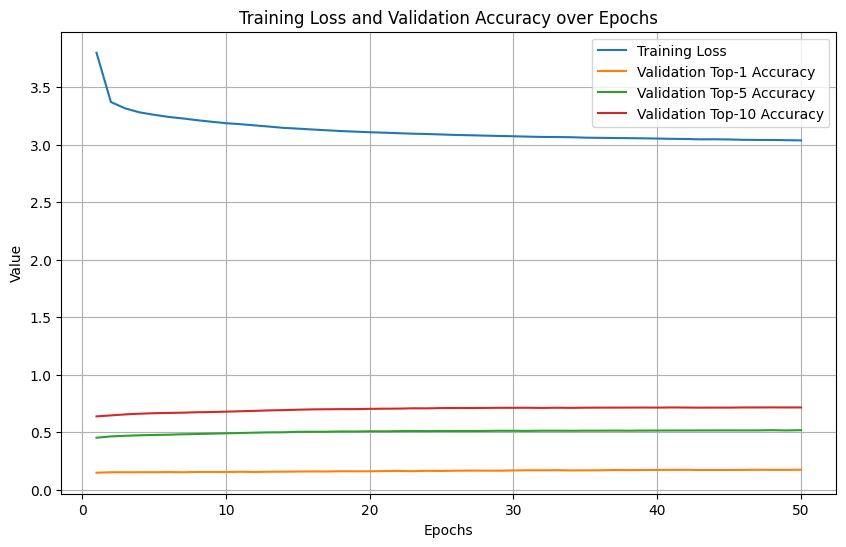

In [91]:
epochs = range(1, len(loss_history) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss_history, label='Training Loss')
plt.plot(epochs, top1_acc_history, label='Validation Top-1 Accuracy')
plt.plot(epochs, top5_acc_history, label='Validation Top-5 Accuracy')
plt.plot(epochs, top10_acc_history, label='Validation Top-10 Accuracy')
plt.title('Training Loss and Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Feature Importance

In [92]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

DegreeRecommender(
  (emb_layers): ModuleList(
    (0-1): 2 x Embedding(10, 5)
    (2-3): 2 x Embedding(21, 11)
    (4): Embedding(2, 1)
  )
  (fc1): Linear(in_features=45, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (out): Linear(in_features=128, out_features=55, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)

🎯 Baseline Accuracy: 0.1754


Calculating permutation importance for numerical features: 100%|██████████| 12/12 [00:00<00:00, 23.53it/s]
Calculating permutation importance for categorical features: 100%|██████████| 5/5 [00:00<00:00, 25.59it/s]


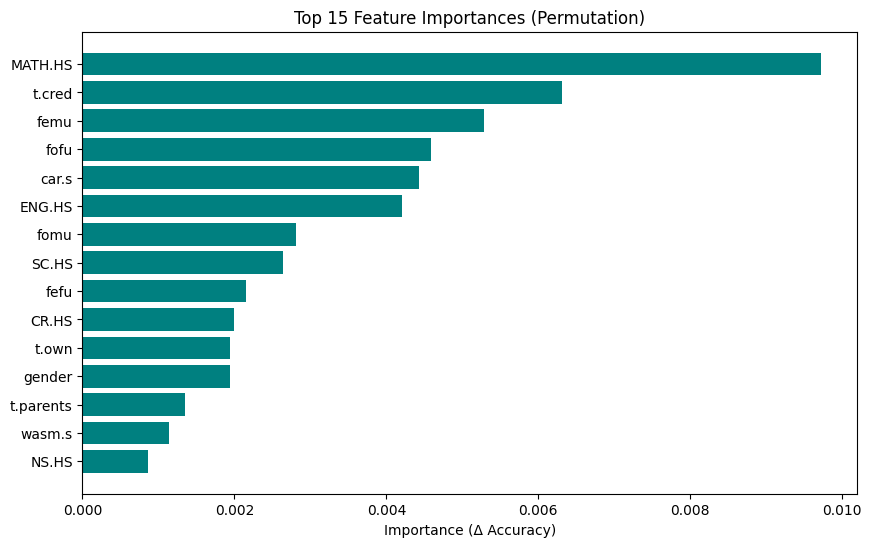

In [93]:
# PERMUTATION FEATURE IMPORTANCE
def permutation_importance(model, X_val_num, X_val_cat, y_val, num_feature_names, cat_feature_names, device='cpu'):
    """
    Compute permutation feature importance for a PyTorch model.
    """
    # Convert pandas DataFrames to PyTorch tensors and move to device
    X_val_num_tensor = torch.tensor(X_val_num.values, dtype=torch.float32).to(device)
    X_val_cat_tensor = torch.tensor(X_val_cat.values, dtype=torch.long).to(device)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.long).to(device)


    # Baseline accuracy
    with torch.no_grad():
        y_pred = model(X_val_cat_tensor, X_val_num_tensor).argmax(dim=1)
        baseline_acc = accuracy_score(y_val_tensor.cpu(), y_pred.cpu())

    print(f"🎯 Baseline Accuracy: {baseline_acc:.4f}")

    feature_importances = []
    # Permute numerical features
    X_val_num_np = X_val_num_tensor.cpu().numpy()
    for i, col in enumerate(tqdm(num_feature_names, desc="Calculating permutation importance for numerical features")):
        X_permuted = X_val_num_np.copy()
        np.random.shuffle(X_permuted[:, i])

        with torch.no_grad():
            y_pred_perm = model(X_val_cat_tensor, torch.tensor(X_permuted, dtype=torch.float32, device=device)).argmax(dim=1)
            perm_acc = accuracy_score(y_val_tensor.cpu(), y_pred_perm.cpu())

        importance = baseline_acc - perm_acc
        feature_importances.append({'Feature': col, 'Importance': importance})

    # Permute categorical features
    X_val_cat_np = X_val_cat_tensor.cpu().numpy()
    for i, col in enumerate(tqdm(cat_feature_names, desc="Calculating permutation importance for categorical features")):
        X_permuted = X_val_cat_np.copy()
        np.random.shuffle(X_permuted[:, i])

        with torch.no_grad():
            y_pred_perm = model(torch.tensor(X_permuted, dtype=torch.long, device=device), X_val_num_tensor).argmax(dim=1)
            perm_acc = accuracy_score(y_val_tensor.cpu(), y_pred_perm.cpu())

        importance = baseline_acc - perm_acc
        feature_importances.append({'Feature': col, 'Importance': importance})


    importance_df = pd.DataFrame(feature_importances).sort_values('Importance', ascending=False)

    return importance_df

# Run permutation importance
importance_df = permutation_importance(model, X_val_num, X_val_cat, pd.Series(y_val), numeric_columns, list(cat_columns), device)

# Plot top 15 permutation importances
plt.figure(figsize=(10, 6))
top_perm = importance_df.head(15)
plt.barh(top_perm['Feature'], top_perm['Importance'], color='teal')
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Permutation)")
plt.xlabel("Importance (Δ Accuracy)")
plt.show()

In [94]:
low_importance_features = importance_df[importance_df['Importance'] < 0.001]
print("Features with importance less than 0.001 (Permutation):")
display(low_importance_features)

Features with importance less than 0.001 (Permutation):


,Feature,Importance
4,NS.HS,0.000863
6,comp.s,0.000540
5,int.s,0.000108


# Training Dropping Unimportant Features

In [95]:
# Identify features to drop
features_to_drop = low_importance_features['Feature'].tolist()
print(f"Features to be dropped: {features_to_drop}")

# Create new dataframes without the unimportant features
X_train_num_dropped = X_train_num.drop(columns=features_to_drop, errors='ignore')
X_test_num_dropped = X_val_num.drop(columns=features_to_drop, errors='ignore')

# Create new datasets and dataloaders
train_ds_dropped = StudentDataset(X_train_num_dropped, X_train_cat, pd.Series(y_train))
val_ds_dropped = StudentDataset(X_test_num_dropped, X_val_cat, pd.Series(y_val))

train_loader_dropped = DataLoader(train_ds_dropped, batch_size=512, shuffle=True)
val_loader_dropped = DataLoader(val_ds_dropped, batch_size=512)

Features to be dropped: ['NS.HS', 'comp.s', 'int.s']


In [96]:
# Initialize a new model with adjusted input dimensions
num_num_features_dropped = X_train_num_dropped.shape[1]
model_dropped = DegreeRecommender(cat_sizes, num_num_features_dropped, hidden_dim=128, num_classes=num_classes)
model_dropped = model_dropped.to(device)

In [97]:
# Define criterion, optimizer, and scheduler for the new model
# Using the same settings as before for consistency
criterion_dropped = nn.CrossEntropyLoss()
optimizer_dropped = optim.AdamW(model_dropped.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_dropped = optim.lr_scheduler.OneCycleLR(
    optimizer_dropped,
    max_lr=3e-3,
    epochs=num_epochs,
    steps_per_epoch=len(train_loader_dropped)
)

In [100]:
# Train the new model
loss_history_dropped, top1_acc_history_dropped, top5_acc_history_dropped, top10_acc_history_dropped = train_model(
    model_dropped, train_loader_dropped, val_loader_dropped, criterion_dropped, optimizer_dropped, scheduler_dropped, num_epochs, device
)

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 1, Loss 3.7394, Top-1 Acc 0.1499, Top-5 Acc 0.4628, Top-10 Acc 0.6412
Epoch 2, Loss 3.3879, Top-1 Acc 0.1516, Top-5 Acc 0.4631, Top-10 Acc 0.6488
Epoch 3, Loss 3.3275, Top-1 Acc 0.1526, Top-5 Acc 0.4671, Top-10 Acc 0.6516
Epoch 4, Loss 3.2959, Top-1 Acc 0.1534, Top-5 Acc 0.4684, Top-10 Acc 0.6559
Epoch 5, Loss 3.2719, Top-1 Acc 0.1534, Top-5 Acc 0.4703, Top-10 Acc 0.6586
Epoch 6, Loss 3.2519, Top-1 Acc 0.1530, Top-5 Acc 0.4715, Top-10 Acc 0.6620
Epoch 7, Loss 3.2360, Top-1 Acc 0.1552, Top-5 Acc 0.4786, Top-10 Acc 0.6669
Epoch 8, Loss 3.2210, Top-1 Acc 0.1559, Top-5 Acc 0.4841, Top-10 Acc 0.6712
Epoch 9, Loss 3.2060, Top-1 Acc 0.1543, Top-5 Acc 0.4858, Top-10 Acc 0.6750
Epoch 10, Loss 3.1931, Top-1 Acc 0.1569, Top-5 Acc 0.4883, Top-10 Acc 0.6794
Epoch 11, Loss 3.1818, Top-1 Acc 0.1573, Top-5 Acc 0.4904, Top-10 Acc 0.6814
Epoch 12, Loss 3.1709, Top-1 Acc 0.1579, Top-5 Acc 0.4910, Top-10 Acc 0.6847
Epoch 13, Loss 3.1599, Top-1 Acc 0.1562, Top-5 Acc 0.4945, Top-10 Acc 0.6881
Epoch 14

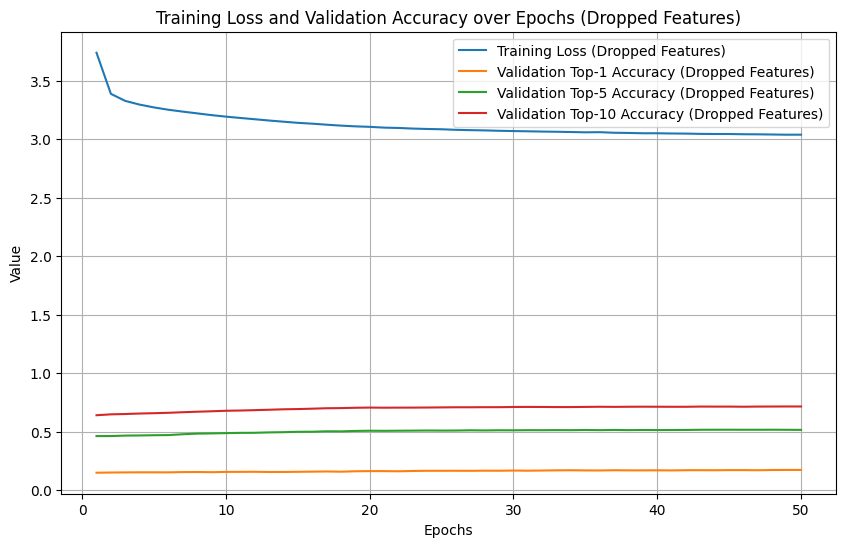

In [101]:
# Visualize the results of the new model
epochs = range(1, len(loss_history_dropped) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss_history_dropped, label='Training Loss (Dropped Features)')
plt.plot(epochs, top1_acc_history_dropped, label='Validation Top-1 Accuracy (Dropped Features)')
plt.plot(epochs, top5_acc_history_dropped, label='Validation Top-5 Accuracy (Dropped Features)')
plt.plot(epochs, top10_acc_history_dropped, label='Validation Top-10 Accuracy (Dropped Features)')
plt.title('Training Loss and Validation Accuracy over Epochs (Dropped Features)')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Export Models

In [ ]:
# Directory to store model
save_dir = "/content/trained_models"
os.makedirs(save_dir, exist_ok=True)

# Save both weights and metadata
model_path = os.path.join(save_dir, "degree_focus_model.pth")
metadata_path = os.path.join(save_dir, "degree_focus_metadata.pt")

# Save model weights
torch.save(model.state_dict(), model_path)


# Ensure objects are serializable
metadata = {
    "label_encoder_classes": list(le_2.classes_),
    "numeric_columns": list(numeric_columns) if not isinstance(numeric_columns, list) else numeric_columns,
    "categorical_columns": list(cat_columns) if not isinstance(cat_columns, list) else cat_columns,
}

# Save metadata (safe for all Python types)
torch.save(metadata, metadata_path)

print(f"✅ Model and metadata saved to: {save_dir}")

✅ Model and metadata saved to: /content/trained_models


In [ ]:
from google.colab import files
files.download(model_path)
files.download(metadata_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>